# Chicago Crime - Exploratory Data Analysis

Discover crime hotspots (location, types), timing patterns, and deeper insights.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/processed/crimes_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)
df.head(3)

Shape: (2441506, 28)


,ID,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,...,DayOfWeek,DayOfWeekName,Hour,Quarter,WeekOfYear,IsWeekend,Lat_bin,Lon_bin,HourBin,Crime_Category
0,14135339,2026-03-13,075XX S KINGSTON AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,0,0,421,...,4,Friday,0,1,11,False,2087,-4379,0,Theft
1,14135179,2026-03-13,050XX N MARINE DR,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - GARAGE,0,0,2024,...,4,Friday,0,1,11,False,2098,-4383,0,Property
2,14138214,2026-03-13,075XX S STONY ISLAND AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,0,0,411,...,4,Friday,0,1,11,False,2087,-4380,0,Violent


## 1. Crime Hotspots by Location

**A) Top Beats by crime count** (Beat = patrol area, primary for police deployment)

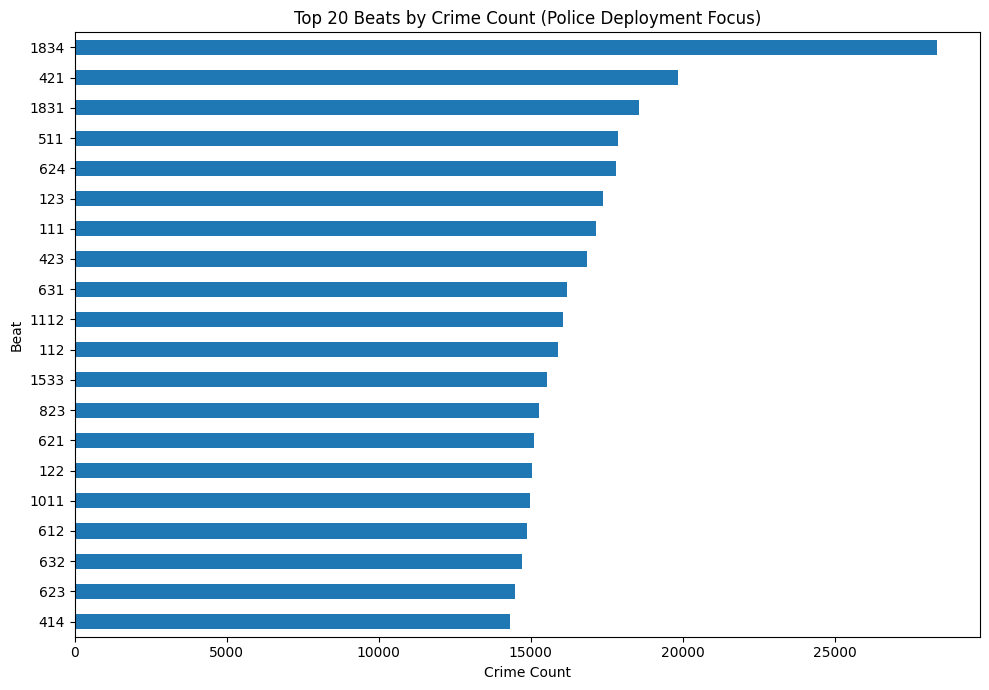

In [14]:
beat_counts = df['Beat'].value_counts().sort_values(ascending=True)
beat_counts.tail(20).plot(kind='barh', figsize=(10, 7), title='Top 20 Beats by Crime Count (Police Deployment Focus)')
plt.xlabel('Crime Count')
plt.tight_layout()
plt.show()

**B) Top Community Areas**

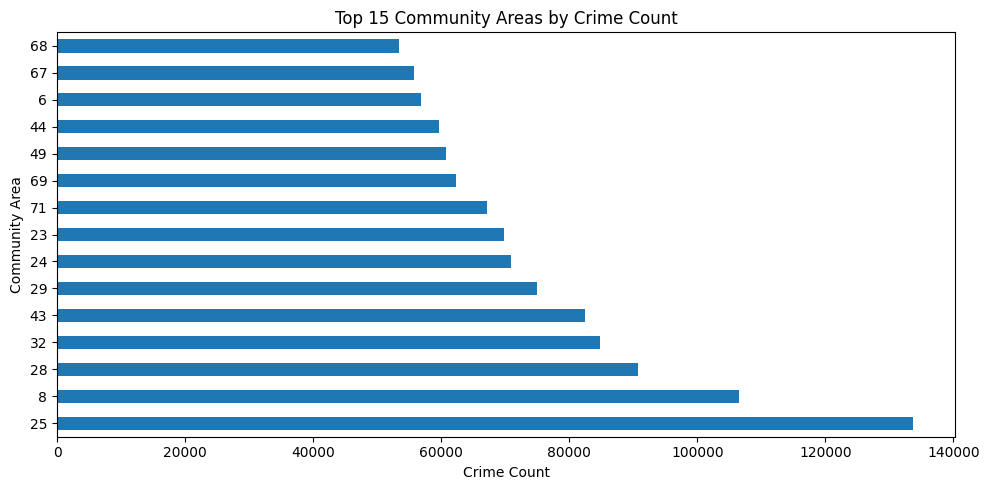

In [15]:
comm = df[df['Community Area'] >= 0]['Community Area'].value_counts().head(15)
comm.plot(kind='barh', figsize=(10, 5), title='Top 15 Community Areas by Crime Count')
plt.xlabel('Crime Count')
plt.tight_layout()
plt.show()

**C) Geographic heatmap (Lat/Lon)**

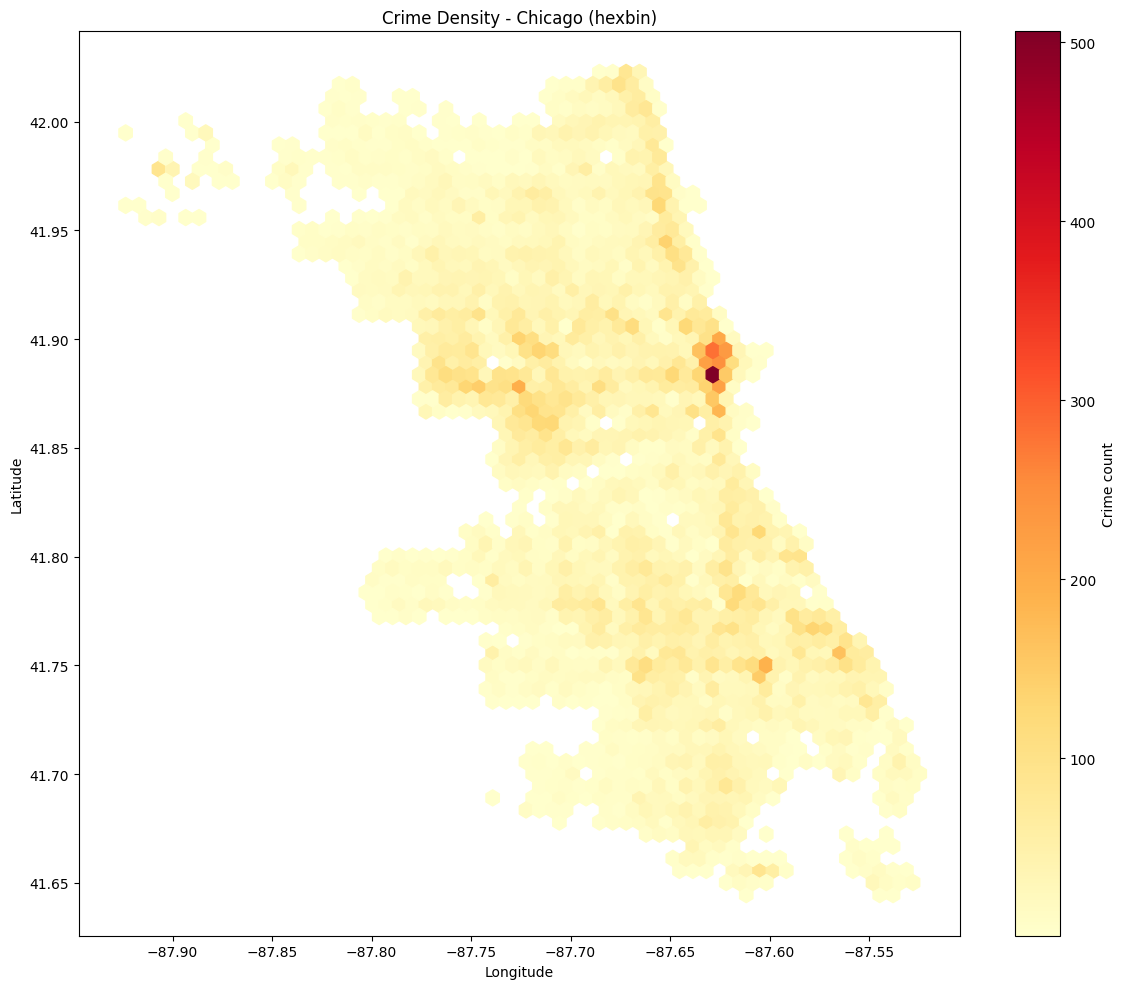

In [16]:
# Sample for faster plotting if dataset is large
sample = df.sample(min(50000, len(df)), random_state=42)
plt.figure(figsize=(12, 10))
plt.hexbin(sample['Longitude'], sample['Latitude'], gridsize=60, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Crime count')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Crime Density - Chicago (hexbin)')
plt.tight_layout()
plt.show()

## 2. Crime Hotspots by Type

Top primary crime types and their proportions.

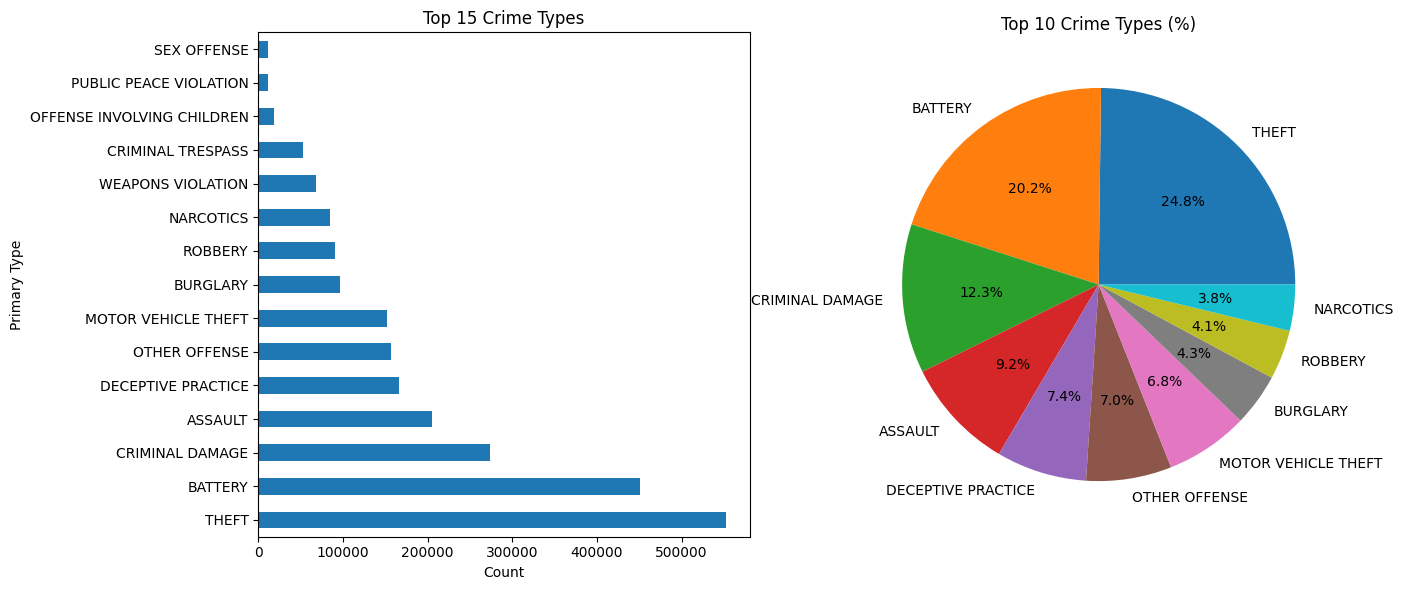

In [17]:
type_counts = df['Primary Type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
type_counts.head(15).plot(kind='barh', ax=axes[0], title='Top 15 Crime Types')
axes[0].set_xlabel('Count')
type_counts.head(10).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', title='Top 10 Crime Types (%)')
plt.tight_layout()
plt.show()

## 3. Crime by Location Description

Where do crimes most frequently occur?

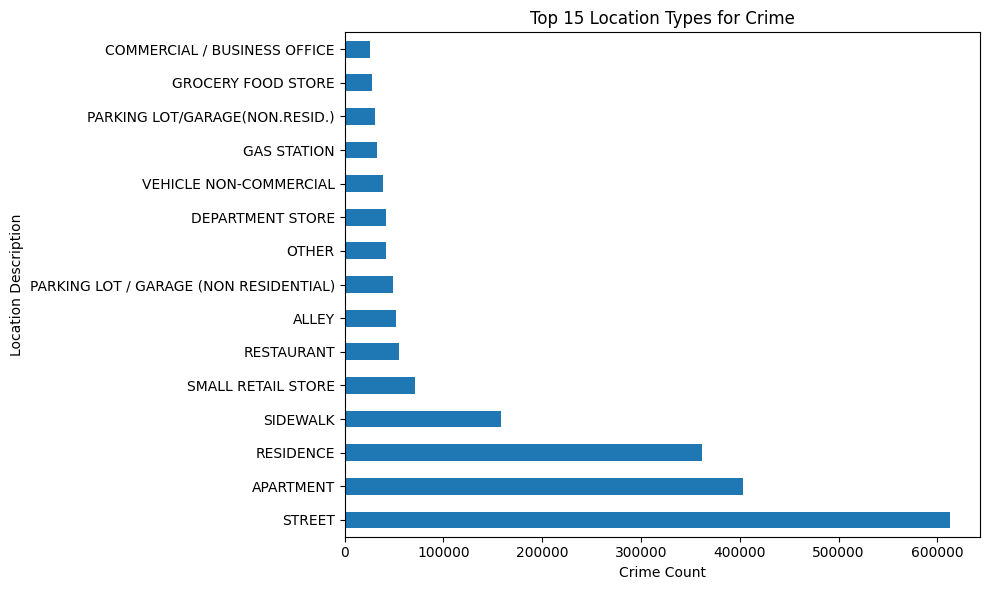

In [18]:
loc_counts = df['Location Description'].value_counts().head(15)
loc_counts.plot(kind='barh', figsize=(10, 6), title='Top 15 Location Types for Crime')
plt.xlabel('Crime Count')
plt.tight_layout()
plt.show()

## 4. Timing Analysis

**A) Crime by Hour of Day**

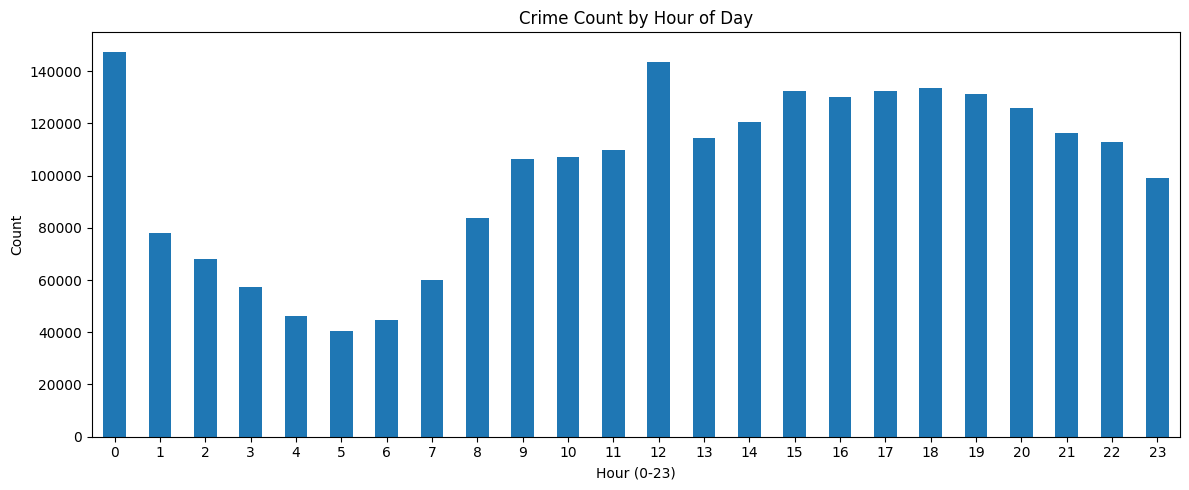

In [19]:
hour_counts = df['Hour'].value_counts().sort_index()
hour_counts.plot(kind='bar', figsize=(12, 5), title='Crime Count by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**B) Crime by Day of Week**

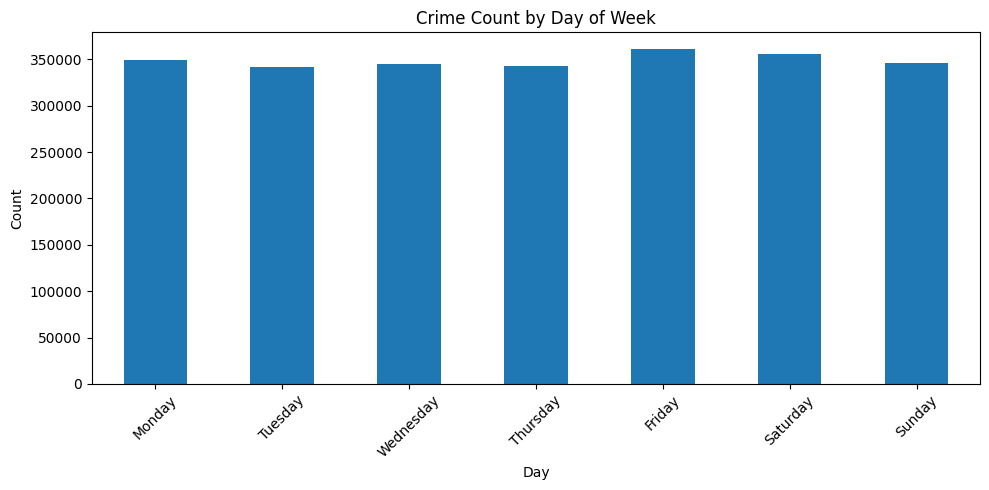

In [20]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['DayOfWeekName'].value_counts().reindex(dow_order)
dow_counts.plot(kind='bar', figsize=(10, 5), title='Crime Count by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**C) Crime by Month**

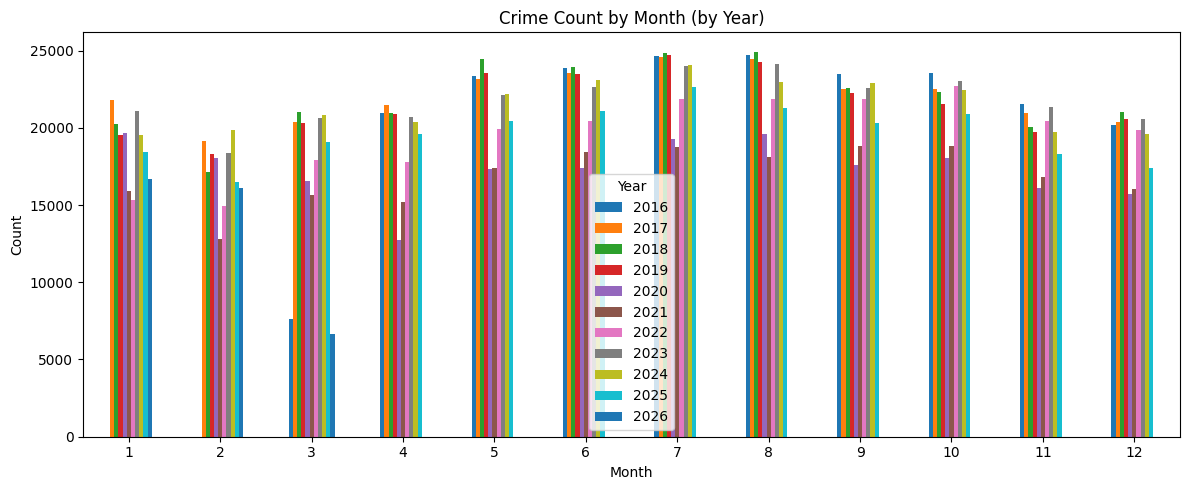

In [21]:
month_counts = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)
month_counts.T.plot(kind='bar', figsize=(12, 5), title='Crime Count by Month (by Year)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Deeper Analysis: Crime Type vs Timing

Heatmap: Top crime types by hour.

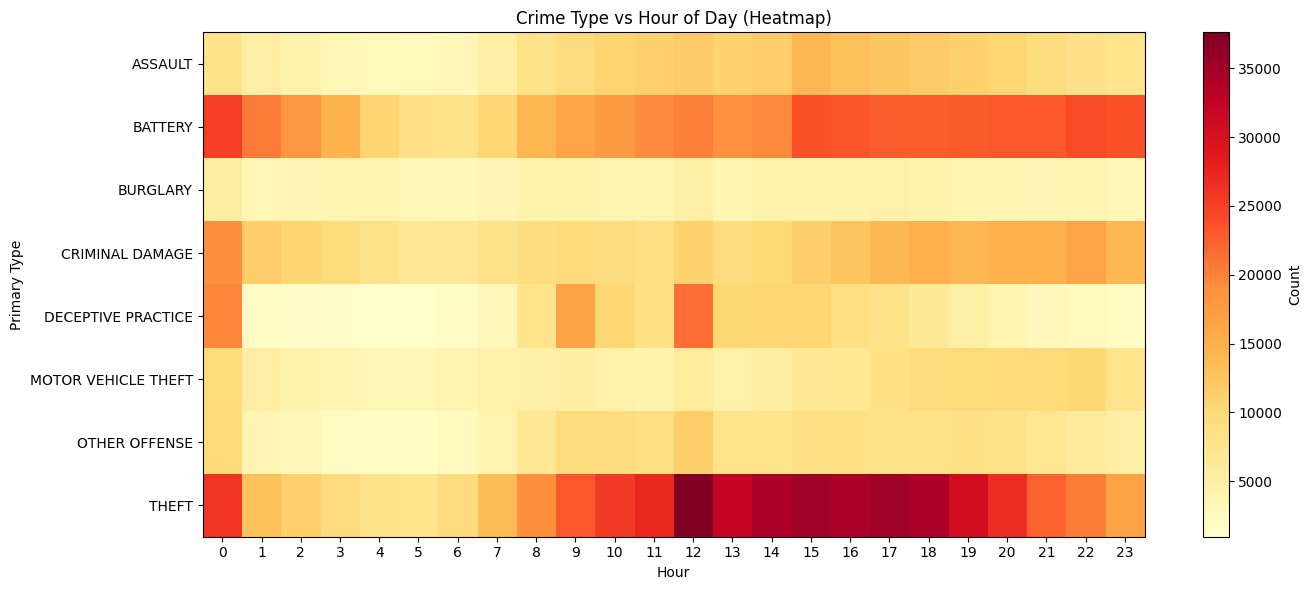

In [22]:
top_types = df['Primary Type'].value_counts().head(8).index
top_df = df[df['Primary Type'].isin(top_types)]
heat_data = top_df.pivot_table(index='Primary Type', columns='Hour', values='ID', aggfunc='count', fill_value=0)
plt.figure(figsize=(14, 6))
plt.imshow(heat_data, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Count')
plt.yticks(range(len(heat_data.index)), heat_data.index)
plt.xticks(range(24), range(24))
plt.xlabel('Hour')
plt.ylabel('Primary Type')
plt.title('Crime Type vs Hour of Day (Heatmap)')
plt.tight_layout()
plt.show()

## 6. Arrest & Domestic Analysis

Proportion of arrests and domestic incidents.

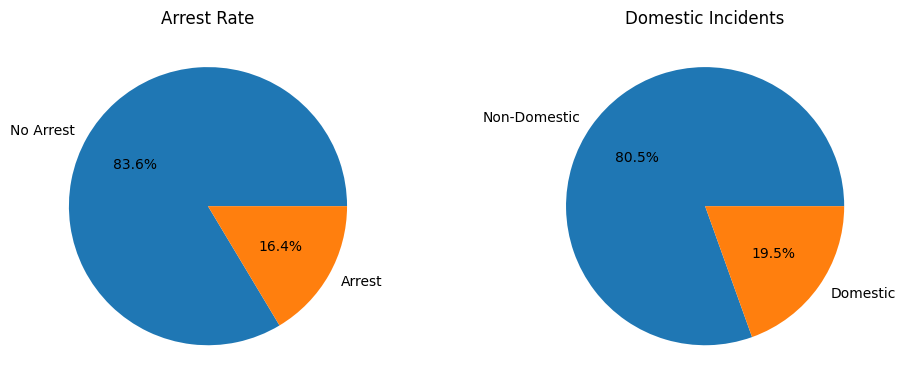

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Arrest'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', labels=['No Arrest', 'Arrest'])
df['Domestic'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['Non-Domestic', 'Domestic'])
axes[0].set_title('Arrest Rate')
axes[1].set_title('Domestic Incidents')
plt.tight_layout()
plt.show()

## 7. Cross-Analysis: Beat vs Crime Type

Top crimes per top beat (for patrol planning).

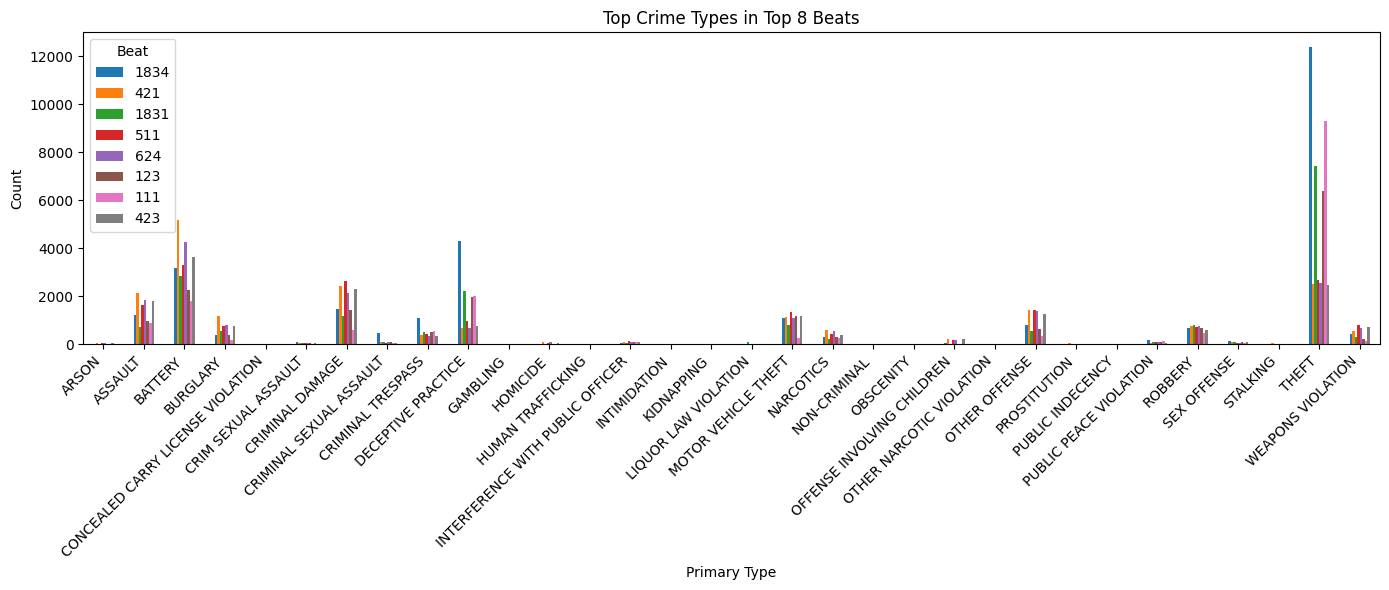

In [24]:
top_beats = df['Beat'].value_counts().head(8).index
beat_type = df[df['Beat'].isin(top_beats)].groupby(['Beat', 'Primary Type']).size().unstack(fill_value=0)
beat_type.loc[top_beats].T.plot(kind='bar', stacked=False, figsize=(14, 6), title='Top Crime Types in Top 8 Beats')
plt.xlabel('Primary Type')
plt.ylabel('Count')
plt.legend(title='Beat')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Weekend vs Weekday Crime

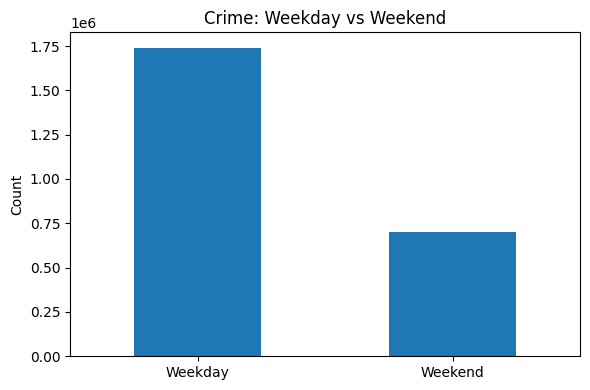

In [25]:
wk = df.groupby('IsWeekend').size()
wk.index = ['Weekday', 'Weekend']
wk.plot(kind='bar', figsize=(6, 4), title='Crime: Weekday vs Weekend')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()